3) Convolutional neural network (CNN) (Any One from the following)  
• Use any dataset of plant disease and design a plant disease detection system using 
CNN.  
• Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into 
categories 

Epoch 1/5


c:\Users\yuvra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7579 - loss: 0.7039
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8531 - loss: 0.4233
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8794 - loss: 0.3520
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8979 - loss: 0.2935
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9129 - loss: 0.2593

CNN MODEL EVALUATION - FASHION MNIST CLASSIFICATION
Test Loss: 0.3726
Test Accuracy: 0.8705 (87.05%)

Macro-Averaged Metrics (equal weight for all classes):
  Precision: 0.8797
  Recall: 0.8713
  F1-Score: 0.8726

Weighted-Averaged Metrics (accounts for class frequency):
  Precision: 0.8788
  Recall: 0.8705
  F1-Score: 0.8718

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.69      0.77       192
     Trouser       0.98      0.96      0.97       192
    Pullover       0.86      0.71      0.78       212
       

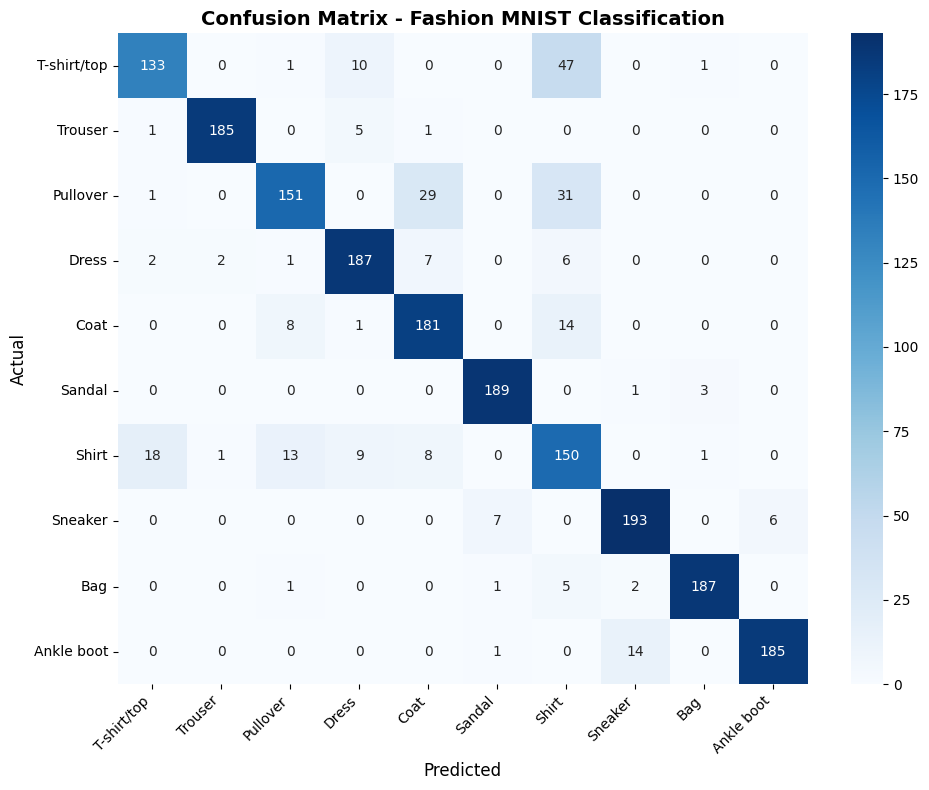


✓ Confusion matrix visualization completed


In [ ]:
# ---------------------------------------------------
# CNN using Fashion MNIST Dataset
# Fashion Clothes Classification
# ---------------------------------------------------

# Import Libraries
import pandas as pd
import numpy as np

# Dataset split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import *

# TensorFlow CNN Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

# ---------------------------------------------------
# STEP 1 : Load Dataset
# ---------------------------------------------------

# Read Fashion MNIST dataset
data = pd.read_csv("fashion-mnist_test.csv")

# ---------------------------------------------------
# STEP 2 : Input and Output
# ---------------------------------------------------

# X -> Image Pixels
# y -> Labels

X = data.drop('label',axis=1).values
y = data['label'].values

# ---------------------------------------------------
# STEP 3 : Normalize Data
# ---------------------------------------------------

# Convert pixel values between 0 and 1

X = X / 255.0

# ---------------------------------------------------
# STEP 4 : Reshape Images
# ---------------------------------------------------

# CNN requires 4D input
# 28 x 28 grayscale image

X = X.reshape(-1,28,28,1)

# ---------------------------------------------------
# STEP 5 : Split Dataset
# ---------------------------------------------------

# 80% -> Training
# 20% -> Testing

X_train,X_test,y_train,y_test = train_test_split(

    X,y,

    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------
# STEP 6 : Build CNN Model
# ---------------------------------------------------

model = Sequential([

    # Convolution Layer
    Conv2D(32,(3,3),

           activation='relu',

           input_shape=(28,28,1)),

    # Max Pooling Layer
    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Hidden Layer
    Dense(64,activation='relu'),

    # Output Layer
    # 10 classes -> softmax

    Dense(10,activation='softmax')
])

# ---------------------------------------------------
# STEP 7 : Compile Model
# ---------------------------------------------------

model.compile(

    optimizer='adam',

    # Multi-class Classification Loss
    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# ---------------------------------------------------
# STEP 8 : Train Model
# ---------------------------------------------------

model.fit(

    X_train,
    y_train,

    epochs=5,
    batch_size=32,

    verbose=1
)

# ---------------------------------------------------
# STEP 9 : Evaluate Model
# ---------------------------------------------------

loss,acc = model.evaluate(

    X_test,
    y_test,

    verbose=0
)

print("\nMODEL EVALUATION\n")

print("Loss =",loss)
print("Accuracy =",acc)

# ---------------------------------------------------
# STEP 10 : Additional Metrics
# ---------------------------------------------------

# Predictions
y_prob = model.predict(X_test,verbose=0)

# Highest probability class
y_pred = np.argmax(y_prob,axis=1)

print("\nPrecision =",

      precision_score(
          y_test,y_pred,
          average='macro'
      ))

print("Recall =",

      recall_score(
          y_test,y_pred,
          average='macro'
      ))

print("F1 Score =",

      f1_score(
          y_test,y_pred,
          average='macro'
      ))

# Confusion Matrix
print("\nConfusion Matrix:\n",

      confusion_matrix(
          y_test,y_pred
      ))

# ---------------------------------------------------
# METRICS EXPLANATION
# ---------------------------------------------------

# Accuracy  -> Correct predictions
# Precision -> Correct positive predictions
# Recall    -> Actual positives found
# F1 Score  -> Balance of Precision & Recall

# ---------------------------------------------------
# STEP 11 : Predict Sample Images
# ---------------------------------------------------

pred = model.predict(X_test[:5],verbose=0)

print("\nSample Predictions:\n")

for i in range(5):

    print(

        "Image",i+1,

        "Predicted =",
        np.argmax(pred[i]),

        "Actual =",
        y_test[i]
    )